In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']

df1 = pd.read_csv("/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/group-housed/behaviour_detection.csv")
df1["condition"] = 'GH'

df2 = pd.read_csv("/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/socially-isolated/behaviour_detection.csv")
df2["condition"] = 'SI'


df = pd.concat([df1, df2], ignore_index=True)

PALETTE = {
    "GH": 'steelblue',     
    "SI": 'darkorange',}

HUE_ORDER = ["GH", "SI"]

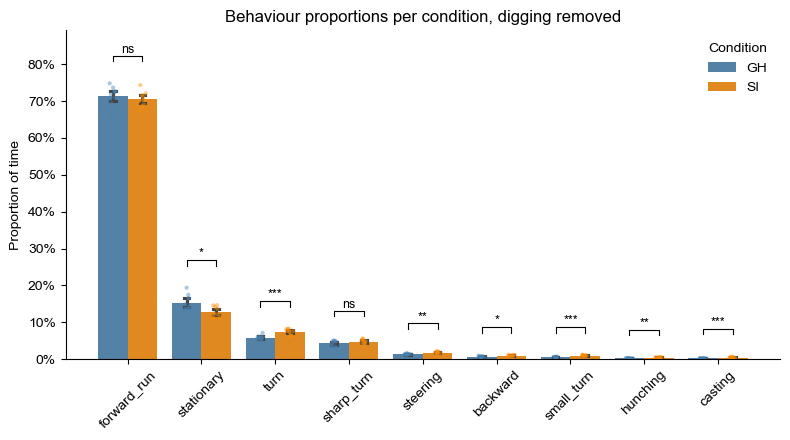

,condition,behaviour,mean_proportion,sem_proportion,mean_n_frames,n_recordings,p_value,significance
0,GH,forward_run,0.714896,0.008028,25119.0,10,0.161972,ns
1,SI,forward_run,0.705278,0.006123,23880.0,10,0.161972,ns
2,GH,stationary,0.153393,0.006410,5374.0,10,0.017257,*
3,SI,stationary,0.127917,0.004371,4325.4,10,0.017257,*
4,GH,turn,0.058509,0.001833,2051.7,10,0.000440,***
5,SI,turn,0.074246,0.002379,2522.3,10,0.000440,***
6,GH,sharp_turn,0.042799,0.002288,1502.6,10,0.140465,ns
7,SI,sharp_turn,0.047443,0.001921,1608.6,10,0.140465,ns
8,GH,steering,0.013382,0.000592,469.8,10,0.002202,**
9,SI,steering,0.017662,0.000903,601.1,10,0.002202,**


In [2]:
# Proportion of time per behaviour, with replicate points, ordering, and stats

import matplotlib.ticker as mtick
from scipy.stats import mannwhitneyu

# remove digging before calculating proportions of time
time_df = df[df["behaviour"] != "digging"].copy()

# total non-digging frames per recording
time_total_frames = (
    time_df.groupby(["file", "condition"])
    .size()
    .reset_index(name="total_frames")
)

# non-digging frames per behaviour per recording
time_behaviour_frames = (
    time_df.groupby(["file", "condition", "behaviour"])
    .size()
    .reset_index(name="n_frames")
)

# add zeros where a recording had no non-digging frames for a behaviour
behaviour_order = sorted(time_df["behaviour"].dropna().unique())
recordings = time_total_frames[["file", "condition", "total_frames"]].drop_duplicates().copy()
behaviours = pd.DataFrame({"behaviour": behaviour_order})
recordings["_key"] = 1
behaviours["_key"] = 1

behaviour_prop_stats = (
    recordings.merge(behaviours, on="_key")
    .drop(columns="_key")
    .merge(time_behaviour_frames, on=["file", "condition", "behaviour"], how="left")
)
behaviour_prop_stats["n_frames"] = behaviour_prop_stats["n_frames"].fillna(0)
behaviour_prop_stats["proportion"] = behaviour_prop_stats["n_frames"] / behaviour_prop_stats["total_frames"]

# order by mean proportion of time across recordings
behaviour_order = (
    behaviour_prop_stats.groupby("behaviour")["proportion"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

condition_order = [c for c in HUE_ORDER if c in behaviour_prop_stats["condition"].unique()]
if len(condition_order) == 0:
    condition_order = sorted(behaviour_prop_stats["condition"].dropna().unique())

palette = PALETTE

def p_to_stars(p_value):
    if pd.isna(p_value):
        return "n/a"
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return "ns"

# Mann-Whitney U per behaviour, comparing per-recording proportions of time
stats_rows = []
if len(condition_order) == 2:
    condition_a, condition_b = condition_order
    for behaviour in behaviour_order:
        values_a = behaviour_prop_stats.loc[
            (behaviour_prop_stats["condition"] == condition_a)
            & (behaviour_prop_stats["behaviour"] == behaviour),
            "proportion",
        ]
        values_b = behaviour_prop_stats.loc[
            (behaviour_prop_stats["condition"] == condition_b)
            & (behaviour_prop_stats["behaviour"] == behaviour),
            "proportion",
        ]

        if len(values_a) > 0 and len(values_b) > 0:
            _, p_value = mannwhitneyu(values_a, values_b, alternative="two-sided")
        else:
            p_value = np.nan

        stats_rows.append({
            "behaviour": behaviour,
            f"n_{condition_a}": len(values_a),
            f"n_{condition_b}": len(values_b),
            "p_value": p_value,
            "significance": p_to_stars(p_value),
        })

stats_table = pd.DataFrame(stats_rows)

plt.figure(figsize=(8, 4.5))
ax = sns.barplot(
    data=behaviour_prop_stats,
    x="behaviour",
    y="proportion",
    hue="condition",
    order=behaviour_order,
    hue_order=condition_order,
    palette=palette,
    errorbar=("ci", 95),
    capsize=0.15,
)
sns.stripplot(
    data=behaviour_prop_stats,
    x="behaviour",
    y="proportion",
    hue="condition",
    order=behaviour_order,
    hue_order=condition_order,
    palette=palette,
    dodge=True,
    alpha=0.45,
    size=3,
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("Proportion of time")
ax.set_title("Behaviour proportions per condition, digging removed")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.tick_params(axis="x", rotation=45)

# add significance brackets
if len(condition_order) == 2 and not stats_table.empty:
    y_max = behaviour_prop_stats["proportion"].max()
    y_step = max(y_max * 0.08, 0.03)
    bracket_height = y_step * 0.25
    ax.set_ylim(0, y_max + y_step * 2.4)

    for x, behaviour in enumerate(behaviour_order):
        y = behaviour_prop_stats.loc[behaviour_prop_stats["behaviour"] == behaviour, "proportion"].max() + y_step
        label = stats_table.loc[stats_table["behaviour"] == behaviour, "significance"].iloc[0]
        x1, x2 = x - 0.2, x + 0.2
        ax.plot([x1, x1, x2, x2], [y, y + bracket_height, y + bracket_height, y], color="black", lw=0.8)
        ax.text(x, y + bracket_height, label, ha="center", va="bottom", fontsize=9)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(condition_order)], labels[:len(condition_order)], title="Condition", frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

summary_table = (
    behaviour_prop_stats.groupby(["condition", "behaviour"], as_index=False)
    .agg(
        mean_proportion=("proportion", "mean"),
        sem_proportion=("proportion", "sem"),
        mean_n_frames=("n_frames", "mean"),
        n_recordings=("file", "nunique"),
    )
)

if not stats_table.empty:
    summary_table = summary_table.merge(
        stats_table[["behaviour", "p_value", "significance"]],
        on="behaviour",
        how="left",
    )

summary_table["behaviour"] = pd.Categorical(summary_table["behaviour"], categories=behaviour_order, ordered=True)
summary_table["condition"] = pd.Categorical(summary_table["condition"], categories=condition_order, ordered=True)
summary_table = summary_table.sort_values(["behaviour", "condition"]).reset_index(drop=True)

display(summary_table)


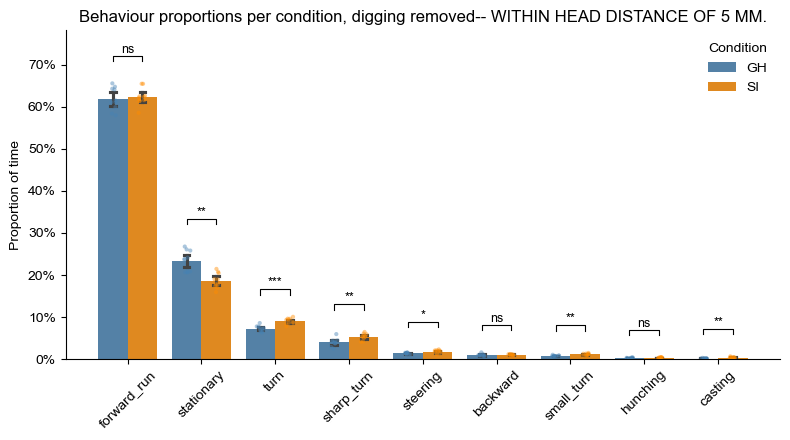

,condition,behaviour,mean_proportion,sem_proportion,mean_n_frames,n_recordings,p_value,significance
0,GH,forward_run,0.618454,0.008525,5051.9,10,0.472676,ns
1,SI,forward_run,0.623250,0.006349,4184.0,10,0.472676,ns
2,GH,stationary,0.233240,0.007734,1934.1,10,0.001315,**
3,SI,stationary,0.186594,0.005693,1260.8,10,0.001315,**
4,GH,turn,0.072889,0.002125,600.8,10,0.000330,***
5,SI,turn,0.090348,0.002222,607.2,10,0.000330,***
6,GH,sharp_turn,0.040115,0.002950,322.3,10,0.007285,**
7,SI,sharp_turn,0.053463,0.002363,361.1,10,0.007285,**
8,GH,steering,0.013852,0.000533,112.3,10,0.025748,*
9,SI,steering,0.017864,0.001224,119.0,10,0.025748,*


In [3]:
# Proportion of time per behaviour, with replicate points, ordering, and stats

import matplotlib.ticker as mtick
from scipy.stats import mannwhitneyu

# remove digging before calculating proportions of time
time_df = df[df["behaviour"] != "digging"].copy()

time_df = time_df[time_df["head_distance"] <= 5].copy()

# total non-digging frames per recording
time_total_frames = (
    time_df.groupby(["file", "condition"])
    .size()
    .reset_index(name="total_frames")
)

# non-digging frames per behaviour per recording
time_behaviour_frames = (
    time_df.groupby(["file", "condition", "behaviour"])
    .size()
    .reset_index(name="n_frames")
)

# add zeros where a recording had no non-digging frames for a behaviour
behaviour_order = sorted(time_df["behaviour"].dropna().unique())
recordings = time_total_frames[["file", "condition", "total_frames"]].drop_duplicates().copy()
behaviours = pd.DataFrame({"behaviour": behaviour_order})
recordings["_key"] = 1
behaviours["_key"] = 1

behaviour_prop_stats = (
    recordings.merge(behaviours, on="_key")
    .drop(columns="_key")
    .merge(time_behaviour_frames, on=["file", "condition", "behaviour"], how="left")
)
behaviour_prop_stats["n_frames"] = behaviour_prop_stats["n_frames"].fillna(0)
behaviour_prop_stats["proportion"] = behaviour_prop_stats["n_frames"] / behaviour_prop_stats["total_frames"]

# order by mean proportion of time across recordings
behaviour_order = (
    behaviour_prop_stats.groupby("behaviour")["proportion"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

condition_order = [c for c in HUE_ORDER if c in behaviour_prop_stats["condition"].unique()]
if len(condition_order) == 0:
    condition_order = sorted(behaviour_prop_stats["condition"].dropna().unique())

palette = PALETTE

def p_to_stars(p_value):
    if pd.isna(p_value):
        return "n/a"
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return "ns"

# Mann-Whitney U per behaviour, comparing per-recording proportions of time
stats_rows = []
if len(condition_order) == 2:
    condition_a, condition_b = condition_order
    for behaviour in behaviour_order:
        values_a = behaviour_prop_stats.loc[
            (behaviour_prop_stats["condition"] == condition_a)
            & (behaviour_prop_stats["behaviour"] == behaviour),
            "proportion",
        ]
        values_b = behaviour_prop_stats.loc[
            (behaviour_prop_stats["condition"] == condition_b)
            & (behaviour_prop_stats["behaviour"] == behaviour),
            "proportion",
        ]

        if len(values_a) > 0 and len(values_b) > 0:
            _, p_value = mannwhitneyu(values_a, values_b, alternative="two-sided")
        else:
            p_value = np.nan

        stats_rows.append({
            "behaviour": behaviour,
            f"n_{condition_a}": len(values_a),
            f"n_{condition_b}": len(values_b),
            "p_value": p_value,
            "significance": p_to_stars(p_value),
        })

stats_table = pd.DataFrame(stats_rows)

plt.figure(figsize=(8, 4.5))
ax = sns.barplot(
    data=behaviour_prop_stats,
    x="behaviour",
    y="proportion",
    hue="condition",
    order=behaviour_order,
    hue_order=condition_order,
    palette=palette,
    errorbar=("ci", 95),
    capsize=0.15,
)
sns.stripplot(
    data=behaviour_prop_stats,
    x="behaviour",
    y="proportion",
    hue="condition",
    order=behaviour_order,
    hue_order=condition_order,
    palette=palette,
    dodge=True,
    alpha=0.45,
    size=3,
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("Proportion of time")
ax.set_title("Behaviour proportions per condition, digging removed-- WITHIN HEAD DISTANCE OF 5 MM.")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.tick_params(axis="x", rotation=45)

# add significance brackets
if len(condition_order) == 2 and not stats_table.empty:
    y_max = behaviour_prop_stats["proportion"].max()
    y_step = max(y_max * 0.08, 0.03)
    bracket_height = y_step * 0.25
    ax.set_ylim(0, y_max + y_step * 2.4)

    for x, behaviour in enumerate(behaviour_order):
        y = behaviour_prop_stats.loc[behaviour_prop_stats["behaviour"] == behaviour, "proportion"].max() + y_step
        label = stats_table.loc[stats_table["behaviour"] == behaviour, "significance"].iloc[0]
        x1, x2 = x - 0.2, x + 0.2
        ax.plot([x1, x1, x2, x2], [y, y + bracket_height, y + bracket_height, y], color="black", lw=0.8)
        ax.text(x, y + bracket_height, label, ha="center", va="bottom", fontsize=9)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(condition_order)], labels[:len(condition_order)], title="Condition", frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

summary_table = (
    behaviour_prop_stats.groupby(["condition", "behaviour"], as_index=False)
    .agg(
        mean_proportion=("proportion", "mean"),
        sem_proportion=("proportion", "sem"),
        mean_n_frames=("n_frames", "mean"),
        n_recordings=("file", "nunique"),
    )
)

if not stats_table.empty:
    summary_table = summary_table.merge(
        stats_table[["behaviour", "p_value", "significance"]],
        on="behaviour",
        how="left",
    )

summary_table["behaviour"] = pd.Categorical(summary_table["behaviour"], categories=behaviour_order, ordered=True)
summary_table["condition"] = pd.Categorical(summary_table["condition"], categories=condition_order, ordered=True)
summary_table = summary_table.sort_values(["behaviour", "condition"]).reset_index(drop=True)

display(summary_table)


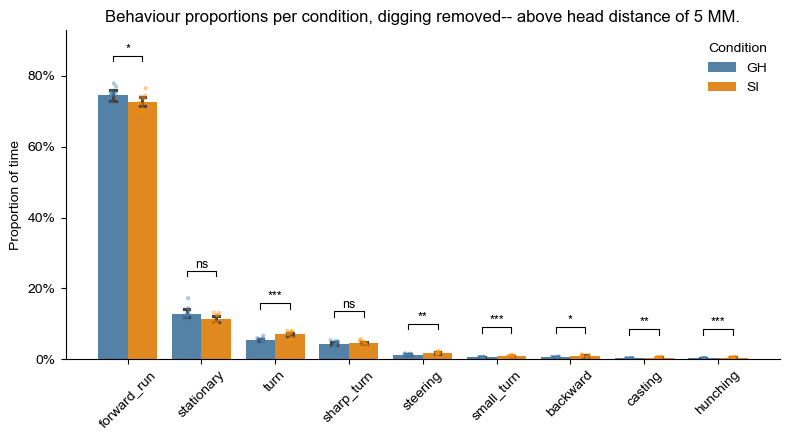

,condition,behaviour,mean_proportion,sem_proportion,mean_n_frames,n_recordings,p_value,significance
0,GH,forward_run,0.745064,0.008365,20066.7,10,0.037635,*
1,SI,forward_run,0.726130,0.006466,19694.4,10,0.037635,*
2,GH,stationary,0.128272,0.006118,3439.9,10,0.140465,ns
3,SI,stationary,0.112977,0.004192,3064.3,10,0.140465,ns
4,GH,turn,0.053969,0.002021,1450.9,10,0.000769,***
5,SI,turn,0.070203,0.002571,1915.1,10,0.000769,***
6,GH,sharp_turn,0.043779,0.002328,1180.3,10,0.623176,ns
7,SI,sharp_turn,0.045854,0.001958,1247.5,10,0.623176,ns
8,GH,steering,0.013235,0.000730,357.5,10,0.002827,**
9,SI,steering,0.017632,0.000879,482.1,10,0.002827,**


In [4]:
# Proportion of time per behaviour, with replicate points, ordering, and stats

import matplotlib.ticker as mtick
from scipy.stats import mannwhitneyu

# remove digging before calculating proportions of time
time_df_2 = df[df["behaviour"] != "digging"].copy()

time_df_2 = time_df_2[time_df_2["head_distance"] >= 5].copy()

# total non-digging frames per recording
time_total_frames = (
    time_df_2.groupby(["file", "condition"])
    .size()
    .reset_index(name="total_frames")
)

# non-digging frames per behaviour per recording
time_behaviour_frames = (
    time_df_2.groupby(["file", "condition", "behaviour"])
    .size()
    .reset_index(name="n_frames")
)



# add zeros where a recording had no non-digging frames for a behaviour
behaviour_order = sorted(time_df_2["behaviour"].dropna().unique())
recordings = time_total_frames[["file", "condition", "total_frames"]].drop_duplicates().copy()
behaviours = pd.DataFrame({"behaviour": behaviour_order})
recordings["_key"] = 1
behaviours["_key"] = 1

behaviour_prop_stats = (
    recordings.merge(behaviours, on="_key")
    .drop(columns="_key")
    .merge(time_behaviour_frames, on=["file", "condition", "behaviour"], how="left")
)
behaviour_prop_stats["n_frames"] = behaviour_prop_stats["n_frames"].fillna(0)
behaviour_prop_stats["proportion"] = behaviour_prop_stats["n_frames"] / behaviour_prop_stats["total_frames"]

# order by mean proportion of time across recordings
behaviour_order = (
    behaviour_prop_stats.groupby("behaviour")["proportion"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

condition_order = [c for c in HUE_ORDER if c in behaviour_prop_stats["condition"].unique()]
if len(condition_order) == 0:
    condition_order = sorted(behaviour_prop_stats["condition"].dropna().unique())

palette = PALETTE

def p_to_stars(p_value):
    if pd.isna(p_value):
        return "n/a"
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return "ns"

# Mann-Whitney U per behaviour, comparing per-recording proportions of time
stats_rows = []
if len(condition_order) == 2:
    condition_a, condition_b = condition_order
    for behaviour in behaviour_order:
        values_a = behaviour_prop_stats.loc[
            (behaviour_prop_stats["condition"] == condition_a)
            & (behaviour_prop_stats["behaviour"] == behaviour),
            "proportion",
        ]
        values_b = behaviour_prop_stats.loc[
            (behaviour_prop_stats["condition"] == condition_b)
            & (behaviour_prop_stats["behaviour"] == behaviour),
            "proportion",
        ]

        if len(values_a) > 0 and len(values_b) > 0:
            _, p_value = mannwhitneyu(values_a, values_b, alternative="two-sided")
        else:
            p_value = np.nan

        stats_rows.append({
            "behaviour": behaviour,
            f"n_{condition_a}": len(values_a),
            f"n_{condition_b}": len(values_b),
            "p_value": p_value,
            "significance": p_to_stars(p_value),
        })

stats_table = pd.DataFrame(stats_rows)

plt.figure(figsize=(8, 4.5))
ax = sns.barplot(
    data=behaviour_prop_stats,
    x="behaviour",
    y="proportion",
    hue="condition",
    order=behaviour_order,
    hue_order=condition_order,
    palette=palette,
    errorbar=("ci", 95),
    capsize=0.15,
)
sns.stripplot(
    data=behaviour_prop_stats,
    x="behaviour",
    y="proportion",
    hue="condition",
    order=behaviour_order,
    hue_order=condition_order,
    palette=palette,
    dodge=True,
    alpha=0.45,
    size=3,
    ax=ax,
)

ax.set_xlabel("")
ax.set_ylabel("Proportion of time")
ax.set_title("Behaviour proportions per condition, digging removed-- above head distance of 5 MM.")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.tick_params(axis="x", rotation=45)

# add significance brackets
if len(condition_order) == 2 and not stats_table.empty:
    y_max = behaviour_prop_stats["proportion"].max()
    y_step = max(y_max * 0.08, 0.03)
    bracket_height = y_step * 0.25
    ax.set_ylim(0, y_max + y_step * 2.4)

    for x, behaviour in enumerate(behaviour_order):
        y = behaviour_prop_stats.loc[behaviour_prop_stats["behaviour"] == behaviour, "proportion"].max() + y_step
        label = stats_table.loc[stats_table["behaviour"] == behaviour, "significance"].iloc[0]
        x1, x2 = x - 0.2, x + 0.2
        ax.plot([x1, x1, x2, x2], [y, y + bracket_height, y + bracket_height, y], color="black", lw=0.8)
        ax.text(x, y + bracket_height, label, ha="center", va="bottom", fontsize=9)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:len(condition_order)], labels[:len(condition_order)], title="Condition", frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

summary_table = (
    behaviour_prop_stats.groupby(["condition", "behaviour"], as_index=False)
    .agg(
        mean_proportion=("proportion", "mean"),
        sem_proportion=("proportion", "sem"),
        mean_n_frames=("n_frames", "mean"),
        n_recordings=("file", "nunique"),
    )
)

if not stats_table.empty:
    summary_table = summary_table.merge(
        stats_table[["behaviour", "p_value", "significance"]],
        on="behaviour",
        how="left",
    )

summary_table["behaviour"] = pd.Categorical(summary_table["behaviour"], categories=behaviour_order, ordered=True)
summary_table["condition"] = pd.Categorical(summary_table["condition"], categories=condition_order, ordered=True)
summary_table = summary_table.sort_values(["behaviour", "condition"]).reset_index(drop=True)

display(summary_table)


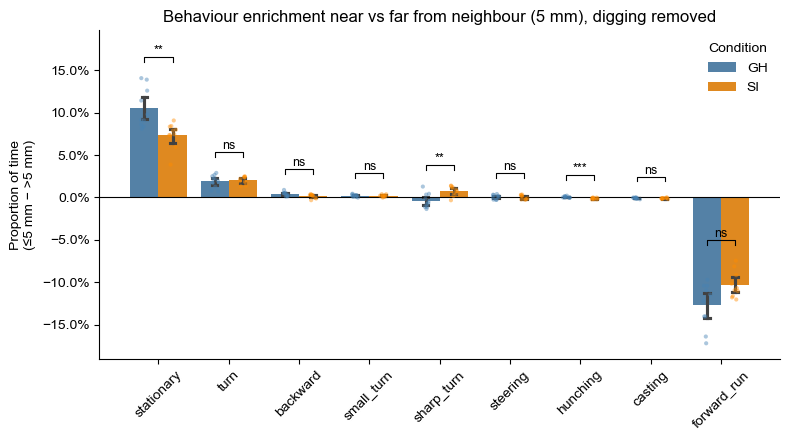

,behaviour,mean_GH,mean_SI,n_GH,n_SI,p_value,significance
0,stationary,0.104968,0.073617,10,10,0.001008,**
1,turn,0.018920,0.020146,10,10,0.850107,ns
2,backward,0.003858,0.001491,10,10,0.121225,ns
3,small_turn,0.002149,0.001936,10,10,0.733730,ns
4,sharp_turn,-0.003664,0.007609,10,10,0.005795,**
5,steering,0.000617,0.000232,10,10,0.969850,ns
6,hunching,0.000543,-0.001173,10,10,0.000583,***
7,casting,-0.000782,-0.000978,10,10,0.273036,ns
8,forward_run,-0.126610,-0.102880,10,10,0.075662,ns


In [5]:
# Near vs far: difference in behaviour proportion (<=5 mm minus >5 mm), GH vs SI
# positive = behaviour done MORE when within 5 mm; negative = more when beyond 5 mm

import matplotlib.ticker as mtick
from scipy.stats import mannwhitneyu

DIST_CUTOFF = 5

near_far_df = df[(df["behaviour"] != "digging") & df["head_distance"].notna()].copy()
near_far_df["zone"] = np.where(near_far_df["head_distance"] <= DIST_CUTOFF, "near", "far")

# frames per recording / zone / behaviour
zone_counts = (
    near_far_df.groupby(["file", "condition", "zone", "behaviour"])
    .size()
    .unstack("behaviour", fill_value=0)
)

# proportion of time within each zone (each row sums to 1)
zone_props = zone_counts.div(zone_counts.sum(axis=1), axis=0)

# near minus far, per recording
near_props = zone_props.xs("near", level="zone")
far_props = zone_props.xs("far", level="zone")
prop_diff = (near_props - far_props).dropna()   # drops recordings missing a zone

prop_diff = (
    prop_diff.reset_index()
    .melt(id_vars=["file", "condition"], var_name="behaviour", value_name="near_minus_far")
)

behaviour_order = (
    prop_diff.groupby("behaviour")["near_minus_far"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

def p_to_stars(p_value):
    if pd.isna(p_value):
        return "n/a"
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return "ns"

# Mann-Whitney U per behaviour: GH vs SI on the near-minus-far difference
stats_rows = []
for behaviour in behaviour_order:
    gh = prop_diff.loc[(prop_diff["condition"] == "GH") & (prop_diff["behaviour"] == behaviour), "near_minus_far"]
    si = prop_diff.loc[(prop_diff["condition"] == "SI") & (prop_diff["behaviour"] == behaviour), "near_minus_far"]
    _, p_value = mannwhitneyu(gh, si, alternative="two-sided")
    stats_rows.append({
        "behaviour": behaviour,
        "mean_GH": gh.mean(),
        "mean_SI": si.mean(),
        "n_GH": len(gh),
        "n_SI": len(si),
        "p_value": p_value,
        "significance": p_to_stars(p_value),
    })

near_far_stats = pd.DataFrame(stats_rows)

plt.figure(figsize=(8, 4.5))
ax = sns.barplot(
    data=prop_diff,
    x="behaviour",
    y="near_minus_far",
    hue="condition",
    order=behaviour_order,
    hue_order=HUE_ORDER,
    palette=PALETTE,
    errorbar=("ci", 95),
    capsize=0.15,
)
sns.stripplot(
    data=prop_diff,
    x="behaviour",
    y="near_minus_far",
    hue="condition",
    order=behaviour_order,
    hue_order=HUE_ORDER,
    palette=PALETTE,
    dodge=True,
    alpha=0.45,
    size=3,
    ax=ax,
)

ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("")
ax.set_ylabel(f"Proportion of time\n(≤{DIST_CUTOFF} mm − >{DIST_CUTOFF} mm)")
ax.set_title(f"Behaviour enrichment near vs far from neighbour ({DIST_CUTOFF} mm), digging removed")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.tick_params(axis="x", rotation=45)

# significance labels above each behaviour
y_top = prop_diff["near_minus_far"].max()
y_bottom = prop_diff["near_minus_far"].min()
y_step = (y_top - y_bottom) * 0.06
for x, behaviour in enumerate(behaviour_order):
    y = prop_diff.loc[prop_diff["behaviour"] == behaviour, "near_minus_far"].max() + y_step
    label = near_far_stats.loc[near_far_stats["behaviour"] == behaviour, "significance"].iloc[0]
    x1, x2 = x - 0.2, x + 0.2
    ax.plot([x1, x1, x2, x2], [y, y + y_step * 0.3, y + y_step * 0.3, y], color="black", lw=0.8)
    ax.text(x, y + y_step * 0.3, label, ha="center", va="bottom", fontsize=9)
ax.set_ylim(y_bottom - y_step, y_top + y_step * 3)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], title="Condition", frameon=False)

sns.despine()
plt.tight_layout()
plt.show()

display(near_far_stats)


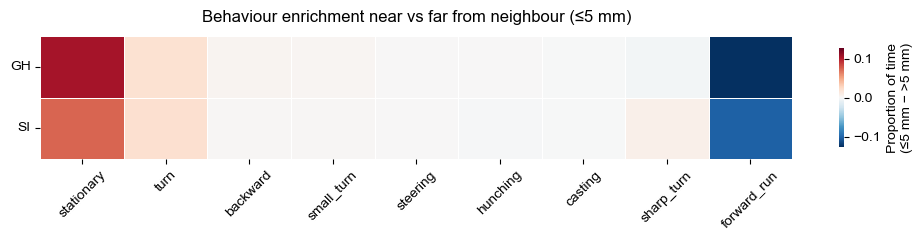

In [6]:
# Heatmap: near-minus-far enrichment by condition and behaviour
DIST_CUTOFF = 5

hm_df = df[(df["behaviour"] != "digging") & df["head_distance"].notna()].copy()
hm_df["zone"] = np.where(hm_df["head_distance"] <= DIST_CUTOFF, "near", "far")

# proportions within each zone per recording
zone_counts = (
    hm_df.groupby(["file", "condition", "zone", "behaviour"])
    .size()
    .unstack("behaviour", fill_value=0)
)
zone_props = zone_counts.div(zone_counts.sum(axis=1), axis=0)

near_props = zone_props.xs("near", level="zone")
far_props  = zone_props.xs("far",  level="zone")
prop_diff  = (near_props - far_props).dropna().reset_index()

prop_diff_long = prop_diff.melt(
    id_vars=["file", "condition"], var_name="behaviour", value_name="near_minus_far"
)

# mean near-minus-far per condition per behaviour
heatmap_data = (
    prop_diff_long.groupby(["condition", "behaviour"])["near_minus_far"]
    .mean()
    .unstack("behaviour")
    .reindex(["GH", "SI"])
)

# order behaviours by GH mean (descending)
behaviour_order = heatmap_data.loc["GH"].sort_values(ascending=False).index.tolist()
heatmap_data = heatmap_data[behaviour_order]

# plot
fig, ax = plt.subplots(figsize=(10, 2.5))
vmax = np.abs(heatmap_data.values).max()

sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap="RdBu_r",
    center=0,
    vmin=-vmax,
    vmax=vmax,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Proportion of time\n(\u22645 mm − >5 mm)", "shrink": 0.8},
    annot=False,
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title(f"Behaviour enrichment near vs far from neighbour (\u2264{DIST_CUTOFF} mm)", pad=10)
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()


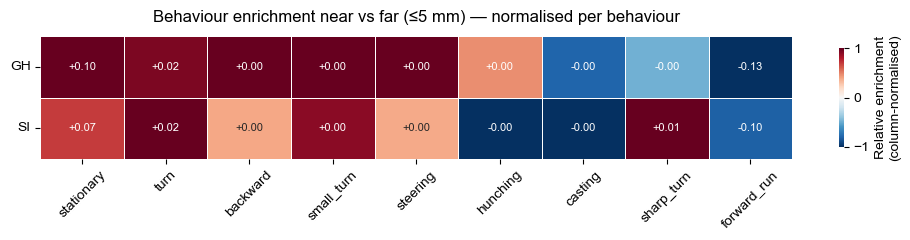

In [7]:
# Heatmap v2: column-normalised so each behaviour fills the full colour range

DIST_CUTOFF = 5

hm_df = df[(df["behaviour"] != "digging") & df["head_distance"].notna()].copy()
hm_df["zone"] = np.where(hm_df["head_distance"] <= DIST_CUTOFF, "near", "far")

zone_counts = (
    hm_df.groupby(["file", "condition", "zone", "behaviour"])
    .size()
    .unstack("behaviour", fill_value=0)
)
zone_props = zone_counts.div(zone_counts.sum(axis=1), axis=0)

near_props = zone_props.xs("near", level="zone")
far_props  = zone_props.xs("far",  level="zone")
prop_diff  = (near_props - far_props).dropna().reset_index()

prop_diff_long = prop_diff.melt(
    id_vars=["file", "condition"], var_name="behaviour", value_name="near_minus_far"
)

heatmap_data = (
    prop_diff_long.groupby(["condition", "behaviour"])["near_minus_far"]
    .mean()
    .unstack("behaviour")
    .reindex(["GH", "SI"])
)

# order by GH enrichment
behaviour_order = heatmap_data.loc["GH"].sort_values(ascending=False).index.tolist()
heatmap_data = heatmap_data[behaviour_order]

# normalise each column by its own max absolute value
# so every behaviour fills the full colour range independently
heatmap_norm = heatmap_data.div(heatmap_data.abs().max(axis=0), axis=1)

# annotate with the raw value so magnitude isn't completely hidden
annot = heatmap_data.applymap(lambda v: f"{v:+.2f}")

fig, ax = plt.subplots(figsize=(10, 2.5))

sns.heatmap(
    heatmap_norm,
    ax=ax,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    annot=annot,
    fmt="",
    annot_kws={"size": 8},
    cbar_kws={"label": "Relative enrichment\n(column-normalised)", "shrink": 0.8},
)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title(f"Behaviour enrichment near vs far (\u2264{DIST_CUTOFF} mm) — normalised per behaviour", pad=10)
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()


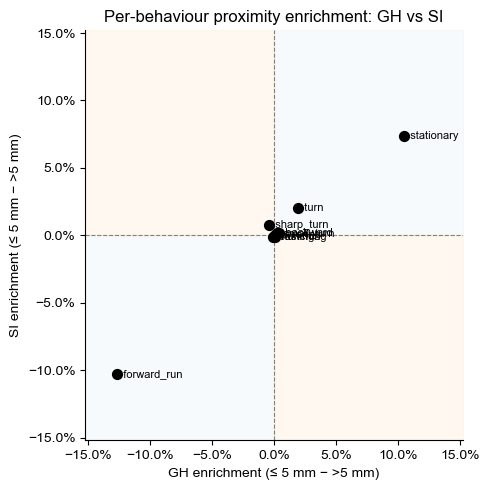

In [8]:
# Scatter: GH enrichment vs SI enrichment (one point per behaviour)
# top-left  = near-enriched in SI only
# bot-right  = near-enriched in GH only
# top-right  = near-enriched in both
# bot-left   = far-enriched in both

DIST_CUTOFF = 5

hm_df = df[(df["behaviour"] != "digging") & df["head_distance"].notna()].copy()
hm_df["zone"] = np.where(hm_df["head_distance"] <= DIST_CUTOFF, "near", "far")

zone_counts = (
    hm_df.groupby(["file", "condition", "zone", "behaviour"])
    .size()
    .unstack("behaviour", fill_value=0)
)
zone_props = zone_counts.div(zone_counts.sum(axis=1), axis=0)

near_props = zone_props.xs("near", level="zone")
far_props  = zone_props.xs("far",  level="zone")
prop_diff  = (near_props - far_props).dropna().reset_index()

prop_diff_long = prop_diff.melt(
    id_vars=["file", "condition"], var_name="behaviour", value_name="near_minus_far"
)

means = (
    prop_diff_long.groupby(["condition", "behaviour"])["near_minus_far"]
    .mean()
    .unstack("condition")
)

fig, ax = plt.subplots(figsize=(5, 5))

ax.axhline(0, color="grey", lw=0.8, ls="--", zorder=0)
ax.axvline(0, color="grey", lw=0.8, ls="--", zorder=0)

ax.scatter(means["GH"], means["SI"], color="black", s=50, zorder=3)

for behaviour, row in means.iterrows():
    ax.text(row["GH"], row["SI"], f"  {behaviour}", fontsize=8, va="center")

lim = max(means.abs().max().max() * 1.2, 0.05)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)

ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("GH enrichment (\u2264 5 mm \u2212 >5 mm)")
ax.set_ylabel("SI enrichment (\u2264 5 mm \u2212 >5 mm)")
ax.set_title("Per-behaviour proximity enrichment: GH vs SI")

# shade quadrants lightly
ax.fill_betweenx([-lim, 0], -lim, 0, color="steelblue",  alpha=0.04)  # far in both
ax.fill_betweenx([0, lim],  0, lim,  color="steelblue",  alpha=0.04)  # near in both
ax.fill_betweenx([0, lim],  -lim, 0, color="darkorange", alpha=0.06)  # SI-only near
ax.fill_betweenx([-lim, 0], 0, lim,  color="darkorange", alpha=0.06)  # GH-only near

sns.despine()
plt.tight_layout()
plt.show()


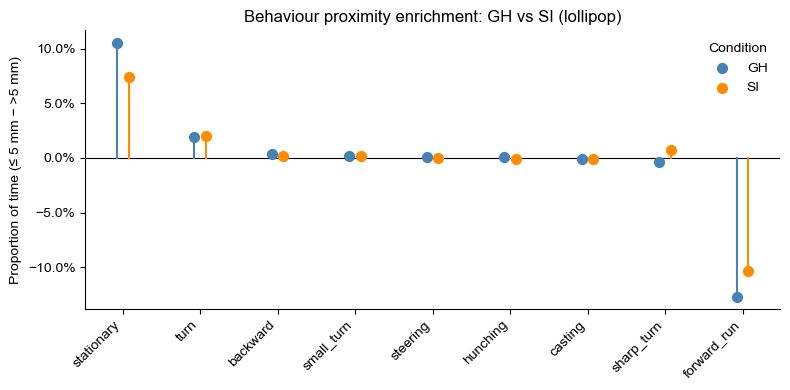

In [9]:
# Lollipop: near-minus-far enrichment, GH vs SI side by side

DIST_CUTOFF = 5

hm_df = df[(df["behaviour"] != "digging") & df["head_distance"].notna()].copy()
hm_df["zone"] = np.where(hm_df["head_distance"] <= DIST_CUTOFF, "near", "far")

zone_counts = (
    hm_df.groupby(["file", "condition", "zone", "behaviour"])
    .size()
    .unstack("behaviour", fill_value=0)
)
zone_props = zone_counts.div(zone_counts.sum(axis=1), axis=0)

near_props = zone_props.xs("near", level="zone")
far_props  = zone_props.xs("far",  level="zone")
prop_diff  = (near_props - far_props).dropna().reset_index()

prop_diff_long = prop_diff.melt(
    id_vars=["file", "condition"], var_name="behaviour", value_name="near_minus_far"
)

means = (
    prop_diff_long.groupby(["condition", "behaviour"])["near_minus_far"]
    .mean()
    .unstack("condition")
)

behaviour_order = means["GH"].sort_values(ascending=False).index.tolist()
means = means.reindex(behaviour_order)

fig, ax = plt.subplots(figsize=(8, 4))

ax.axhline(0, color="black", lw=0.8, zorder=0)

offset = 0.15
for i, behaviour in enumerate(behaviour_order):
    for j, (cond, color) in enumerate(PALETTE.items()):
        x = i + (j - 0.5) * offset
        y = means.loc[behaviour, cond]
        ax.plot([x, x], [0, y], color=color, lw=1.5, zorder=1)
        ax.scatter(x, y, color=color, s=50, zorder=2, label=cond if i == 0 else "")

ax.set_xticks(range(len(behaviour_order)))
ax.set_xticklabels(behaviour_order, rotation=45, ha="right")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel("Proportion of time (\u2264 5 mm \u2212 >5 mm)")
ax.set_title("Behaviour proximity enrichment: GH vs SI (lollipop)")
ax.legend(title="Condition", frameon=False)

sns.despine()
plt.tight_layout()
plt.show()


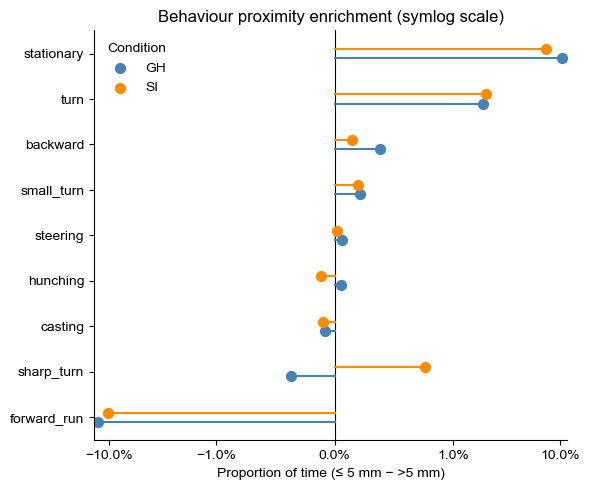

In [10]:
# Lollipop v2: horizontal, GH vs SI, symlog x-axis so small behaviours are visible

DIST_CUTOFF = 5

hm_df = df[(df["behaviour"] != "digging") & df["head_distance"].notna()].copy()
hm_df["zone"] = np.where(hm_df["head_distance"] <= DIST_CUTOFF, "near", "far")

zone_counts = (
    hm_df.groupby(["file", "condition", "zone", "behaviour"])
    .size()
    .unstack("behaviour", fill_value=0)
)
zone_props = zone_counts.div(zone_counts.sum(axis=1), axis=0)

near_props = zone_props.xs("near", level="zone")
far_props  = zone_props.xs("far",  level="zone")
prop_diff  = (near_props - far_props).dropna().reset_index()

prop_diff_long = prop_diff.melt(
    id_vars=["file", "condition"], var_name="behaviour", value_name="near_minus_far"
)

means = (
    prop_diff_long.groupby(["condition", "behaviour"])["near_minus_far"]
    .mean()
    .unstack("condition")
)

# order by GH mean
behaviour_order = means["GH"].sort_values(ascending=True).index.tolist()  # ascending = top of plot is most enriched
means = means.reindex(behaviour_order)

fig, ax = plt.subplots(figsize=(6, 5))

ax.axvline(0, color="black", lw=0.8, zorder=0)

offset = 0.2
for i, behaviour in enumerate(behaviour_order):
    for j, (cond, color) in enumerate(PALETTE.items()):
        y = i + (j - 0.5) * offset
        x = means.loc[behaviour, cond]
        ax.plot([0, x], [y, y], color=color, lw=1.5, zorder=1)
        ax.scatter(x, y, color=color, s=50, zorder=2, label=cond if i == 0 else "")

ax.set_yticks(range(len(behaviour_order)))
ax.set_yticklabels(behaviour_order)
ax.set_xscale("symlog", linthresh=0.01)  # linear between -0.01 and 0.01, log outside
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Proportion of time (\u2264 5 mm \u2212 >5 mm)")
ax.set_title("Behaviour proximity enrichment (symlog scale)")
ax.legend(title="Condition", frameon=False)

sns.despine()
plt.tight_layout()
plt.show()


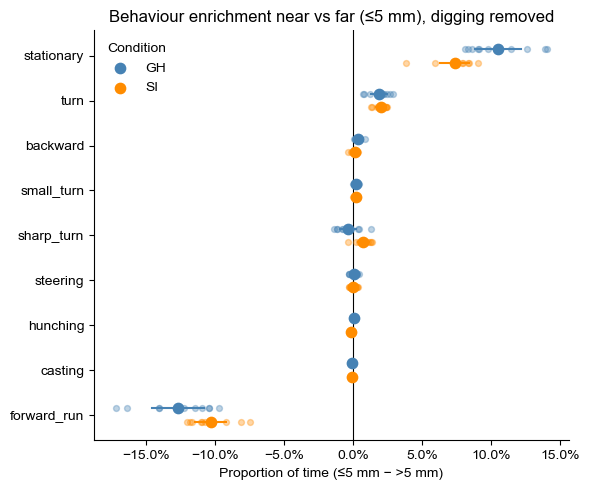

In [11]:
# Dot plot: near-minus-far enrichment, individual animals + mean + CI
# styled like bout-initiation composition plot

from scipy import stats as sp_stats

DIST_CUTOFF = 5

hm_df = df[(df["behaviour"] != "digging") & df["head_distance"].notna()].copy()
hm_df["zone"] = np.where(hm_df["head_distance"] <= DIST_CUTOFF, "near", "far")

zone_counts = (
    hm_df.groupby(["file", "condition", "zone", "behaviour"])
    .size()
    .unstack("behaviour", fill_value=0)
)
zone_props = zone_counts.div(zone_counts.sum(axis=1), axis=0)

near_props = zone_props.xs("near", level="zone")
far_props  = zone_props.xs("far",  level="zone")
prop_diff  = (near_props - far_props).dropna().reset_index()

prop_diff_long = prop_diff.melt(
    id_vars=["file", "condition"], var_name="behaviour", value_name="near_minus_far"
)

# order behaviours by overall mean (most near-enriched at top)
behaviour_order = (
    prop_diff_long.groupby("behaviour")["near_minus_far"]
    .mean()
    .sort_values(ascending=True)
    .index.tolist()
)

n_behaviours = len(behaviour_order)
offsets = {"GH": 0.15, "SI": -0.15}

fig, ax = plt.subplots(figsize=(6, 5))
ax.axvline(0, color="black", lw=0.8, zorder=0)

for i, behaviour in enumerate(behaviour_order):
    for cond, color in PALETTE.items():
        vals = prop_diff_long.loc[
            (prop_diff_long["behaviour"] == behaviour) &
            (prop_diff_long["condition"] == cond),
            "near_minus_far"
        ]
        y = i + offsets[cond]

        # individual points
        ax.scatter(
            vals, [y] * len(vals),
            color=color, alpha=0.35, s=18, zorder=2
        )

        # mean + 95% CI
        mean = vals.mean()
        ci = sp_stats.sem(vals) * sp_stats.t.ppf(0.975, df=len(vals)-1) if len(vals) > 1 else 0
        ax.plot([mean - ci, mean + ci], [y, y], color=color, lw=1.5, zorder=3)
        ax.scatter(mean, y, color=color, s=55, zorder=4,
                   label=cond if i == 0 else "")

ax.set_yticks(range(n_behaviours))
ax.set_yticklabels(behaviour_order)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel(f"Proportion of time (\u2264{DIST_CUTOFF} mm \u2212 >{DIST_CUTOFF} mm)")
ax.set_title(f"Behaviour enrichment near vs far (\u2264{DIST_CUTOFF} mm), digging removed")
ax.legend(title="Condition", frameon=False)

sns.despine()
plt.tight_layout()
plt.show()
